# Linear Regression

## Supervised Learning

As the word suggests in supervised learning both the input data (features) and the target (label) is provided. A machine learning model is created, trained and evaluated using the provided labeled data. The model is a function that maps from input to output. 

Given a training set of $N$ example input-output pairs $(x_{1},y_{1}),(x_{2},y_{2})....(x_{n},y_{n})$ where each $y_{i}$ is generated by an unknown function $y=f(x)$ ;a supervised learning algorithm discovers a function $h$ that approximate the true function $f$. Here $y$ can be any value. It is not required that it is a number. In order to evaluate the approximation ability of the function (model) we test the known $y$ for known $x$ which was not used in creating the function $h$. Then we pass $x$ through the $h$ and compare the result obtained with the actual value. This gives us accuracy.

## Regression

**Regression**

Regression Analysis is used for determining the statistical relationship between a dependent
variable (usually denoted by $y$) and one or more independent variable (usually denoted by $X$).

**Dependent Variable**: It is something that you want to predict or explain. It can be something
like a price of a house, price of stock next hour, amount of money that will be withdrawn from
ATM in next hour and so on and so forth.

**Independent Variable**: They are the values that are used to explain or predict the dependent
variable. To predict the house price, values like number of rooms, area of land, distance from store
etc.

The primary goal is to fit a linear equation to the observed data. This equation can then be used to predict future values, understand relationships, and identify trends.

### Simple Linear Regression
A statistical method that allows us to summarize and study relationships between two continuous (quantitative) variables:
* One variable, denoted $x$, is regarded as the predictor, explanatory, or independent variable.
* The other variable, denoted $y$, is regarded as the response, outcome, or dependent variable.

Simple linear regression gets its adjective "simple," because it concerns the study of only one predictor variable. In contrast, multiple linear regression, which we study later in this course, gets its adjective "multiple," because it concerns the study of two or more predictor/independent variables.

Mathematically, we can write this linear relationship as
$$Y=\beta_{0}+\beta_{1}X+\epsilon$$

Where
* Y is the dependent variable. This is the value we want to predict
* $\beta_0$ is the Y-intercept
* $\beta_1$ is the slope
* $X$ is the independent variable
* $\epsilon$ is the error that can not be explained by the model

Together $\beta_0$ and $\beta_1$ are called **coefficients** or **parameters**

We can compute the value of y for new value of x by

$$\hat{y}=\beta_0+\beta_1x$$

The predicted value of $y$ is usually denoted by $\hat{y}$ `y hat`

### How to Compute $\beta_0$ and $\beta_1$?

Our goal in linear regression is to get the equation of the best fit line to the data.

![Linear Regression](images/lr_ols.png)

The best fit line is the one which have error in some overall sense. In general, when we use $\hat{y}=\beta_0+\beta_1x_i$ to predict the actual response $y_i$, we make a prediction error (or residual error) of size:

$$e_i=y_i-\hat{y}_i$$

One way to achieve this goal is to invoke the **least squares criterion**, which says to **minimize the sum of the squared prediction errors**. We need to find $\beta_0$ and $\beta_1$ such that the term

$$\sum_{i=1}^n(y_i-\hat{y_{i}})^2$$

is minimized. This term is called **Sum of Square Errors (SSE)**.      

$$SSE = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

To find $( \beta_0 $) and $( \beta_1 $) that minimize SSE, we take the partial derivatives of SSE with respect to $( \beta_0 $) and $( \beta_1 $) and set them to zero.

$$\frac{\partial SSE}{\partial \beta_0} = -2 \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i) = 0$$

$$\frac{\partial SSE}{\partial \beta_1} = -2 \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i) x_i = 0$$


Solving the two equations above we get

## $$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

## $$\beta_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/lifesat.csv")

In [3]:
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


In [4]:
df.drop(columns=['Country'], inplace=True)

In [5]:
df.head()

,GDP per capita (USD),Life satisfaction
0,26456.387938,5.8
1,27287.083401,5.4
2,28384.987785,5.5
3,29932.493910,5.9
4,31007.768407,5.6


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GDP per capita (USD)  27 non-null     float64
 1   Life satisfaction     27 non-null     float64
dtypes: float64(2)
memory usage: 564.0 bytes


In [8]:
df.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


In [9]:
df=df.rename(columns={'GDP per capita (USD)':'pci','Life satisfaction':'lf_sat'})

In [9]:
df.head()

,pci,lf_sat
0,26456.387938,5.8
1,27287.083401,5.4
2,28384.987785,5.5
3,29932.493910,5.9
4,31007.768407,5.6


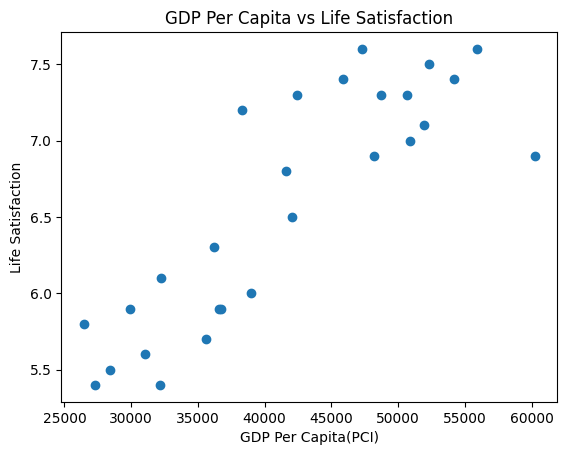

In [11]:
plt.scatter(df['pci'],df['lf_sat'])
plt.xlabel('GDP Per Capita(PCI)')
plt.ylabel('Life Satisfaction')
plt.title('GDP Per Capita vs Life Satisfaction')
plt.savefig('fig1.png')
plt.show()

## Lab 1: 
Task 1: Implement the Simple Linear Regression in the [Lifesat Dataset](https://github.com/ageron/data/blob/main/lifesat/lifesat.csv) to get the coefficient 

## Assumptions of Linear Regression

There are five major assumptions of linear regression. They are

1. There is a Linear Relationship Between Dependent and Independent Variables
2. No Multi collinearity
3. Normality of Residuals (Error)
4. Homoscedasticity
5. No Autocorrelation Between Error Terms

Let's Look at them individually with examples of testing them out with Python. For this, we will be using the Salary Dataset.  

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("datasets/Salary_Dataset.csv")

In [14]:
df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


Here **Age** and **Years of Experience** are the independent variables and **Salary** is the dependent variable.

### 1. Linear Relationship Between Dependent and Independent Variables

![Linear and Non Linear Relationship](images/bivariate-relations.png)

To test this assumption we can plot a scatter plot to see the relationship between each independent variable and dependent variable

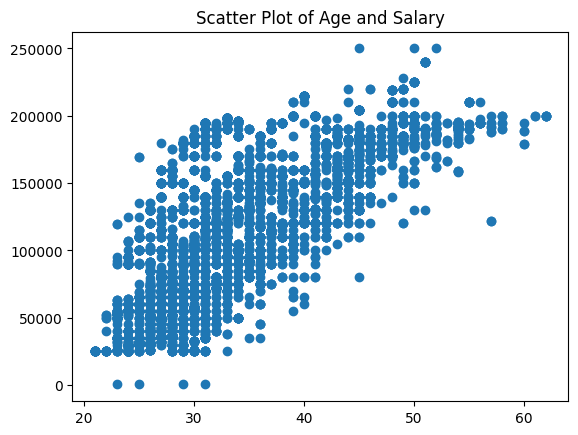

In [15]:
plt.scatter(df['Age'],df['Salary'])
plt.title('Scatter Plot of Age and Salary')
plt.show()

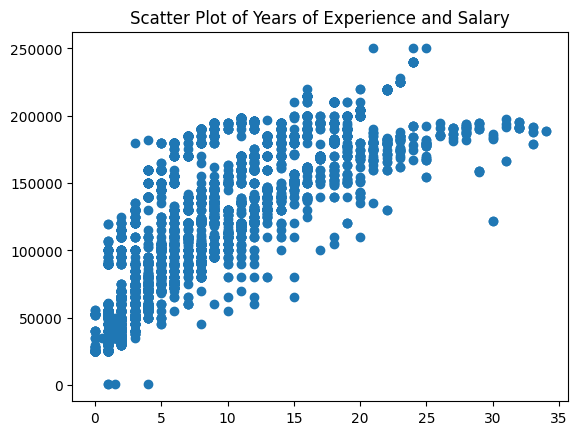

In [16]:
plt.scatter(df['Years of Experience'],df['Salary'])
plt.title('Scatter Plot of Years of Experience and Salary')
plt.show()

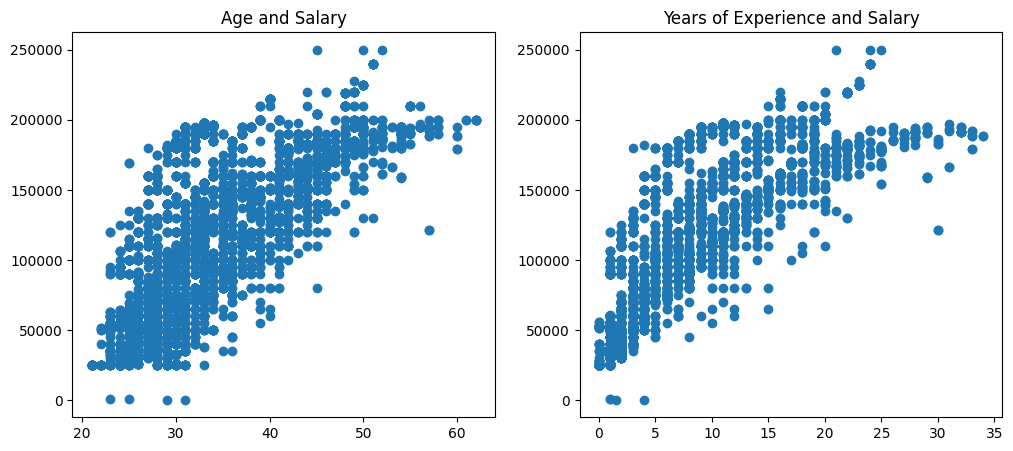

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(df['Age'], df['Salary'])
ax1.set_title("Age and Salary")
ax2.scatter(df['Years of Experience'], df['Salary'])
ax2.set_title("Years of Experience and Salary")
plt.show()

### 2. No Multicollinearity
Independent variables should not be highly correlated with each other.

We can test this assumption in two ways
1. Variance Inflation Factor (VIF)
2. Correlation Matrix

In [18]:
df = df.dropna()

In [19]:
df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


In [24]:
df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


In [20]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [27]:
X

,Age,Years of Experience
0,32.0,5.0
1,28.0,3.0
2,45.0,15.0
3,36.0,7.0
4,52.0,20.0
...,...,...
6699,49.0,20.0
6700,32.0,3.0
6701,30.0,4.0
6702,46.0,14.0


In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
model.coef_

array([-1827.26621759,  9093.66913273])

In [31]:
model.intercept_

np.float64(103377.01635503271)

In [32]:
# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [34]:
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 

In [40]:
X.shape[1]

2

In [35]:
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X, i) 
                          for i in range((X.shape[1]))] 

In [36]:
vif_data

,feature,VIF
0,Age,5.520692
1,Years of Experience,5.520692


If the value of VIF is greater than 10, we remove that variable. If there are multiple variables with VIF greater than 10, we remove only the variables with the largest VIF value and re-run the model. 

In [41]:
df.corr()

,Age,Years of Experience,Salary
Age,1.000000,0.937694,0.728053
Years of Experience,0.937694,1.000000,0.808969
Salary,0.728053,0.808969,1.000000


We can also look at the Correlation Matrix to see if the value of the correlation coefficient between independent variable is high.

<Axes: >

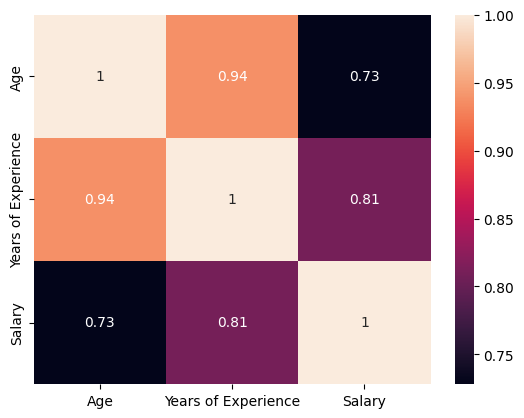

In [29]:
sns.heatmap(df.corr(),annot=True)

### 3. Normality of Residual

We can plot the distribution of the 

<Axes: xlabel='Salary', ylabel='Count'>

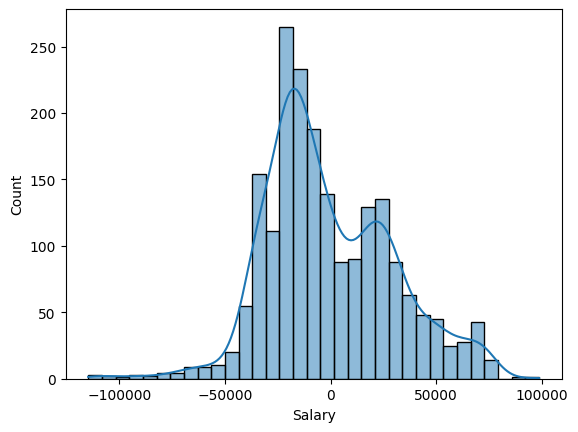

In [42]:
sns.histplot(residual,kde=True)

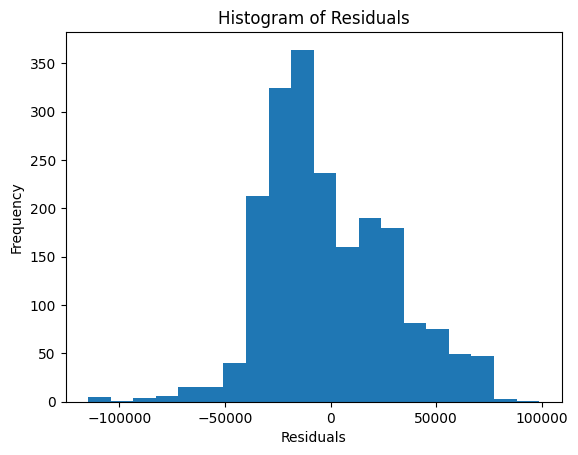

In [31]:
# Histogram of residuals
plt.hist(residual, bins=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

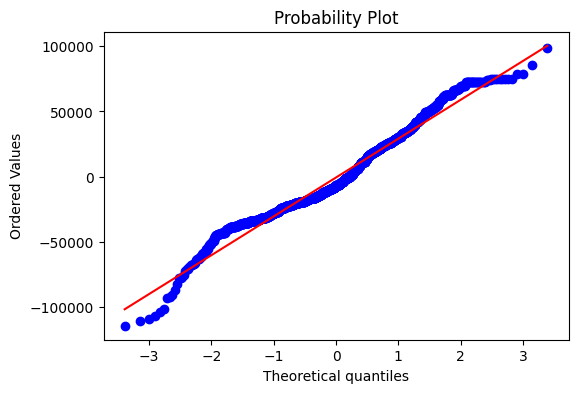

In [43]:
import scipy as sp
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

### 4. Homoscedasticity

Homoscedasticity, or homogeneity of variances, is an assumption of equal or similar variances in different groups being compared. We can test it with the help of a scatter plot of predicted values and residual

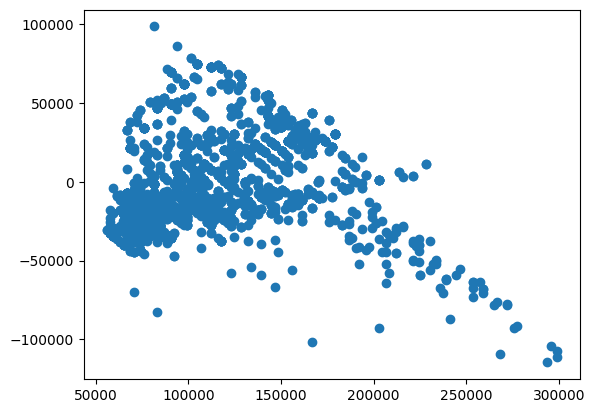

In [33]:
plt.scatter(y_pred,residual)

### 5. No Autocorrelation Between Error Terms

The current error term should not be dependent on the previous error term. We can use the line plot of residuals to inspect if there is autocorrelation between error terms visually. To statistically test it we can use Durbin-Watson Test 

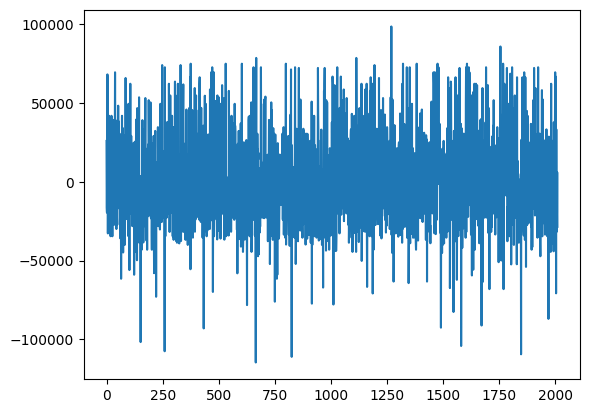

In [34]:
plt.plot(residual.values)

In [44]:
from statsmodels.stats.stattools import durbin_watson

# Durbin-Watson test
dw_test = durbin_watson(residual)
print(f'Durbin-Watson test statistic: {dw_test}')

Durbin-Watson test statistic: 2.005201451724819


**DW value between 1.5 and 2.5 suggests no autocorrelation.**

## Evaluation for Linear Regression

We evaluate the Linear Regression model with the help of various metrics. 

### 1. Mean Absolute Error (MAE)

MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$$


### 2. Mean Squared Error (MSE)
MSE measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


### 3. Root Mean Squared Error (RMSE)

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$


 ### 4. R-squared (R²)
 R-squared measures the proportion of the variance in the dependent variable that is predictable from the independent variables. It indicates how well the data points fit a linear regression model. For example if the value of $R^2$ is 0.85, it means that the independent variable can explain 85% variance in the dependent variable.

$$ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

**Total Sum of Squares (TSS)**

$$\text{TSS} = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

**Sum of Squared Errors (SSE)**
$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


$$R^2 = \frac{\text{ESS}}{\text{TSS}} = 1 - \frac{\text{SSE}}{\text{TSS}}$$


In [36]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming y_test and y_pred are already defined

# R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.5f}')

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae:.5f}')

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse:.5f}')

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.5f}')


R-squared: 0.67596
Mean Absolute Error (MAE): 24586.13885
Mean Squared Error (MSE): 914408954.95174
Root Mean Squared Error (RMSE): 30239.19567


## Linear Regression With Gradient Descent
![Getting Down the Hill](images/gd_mount.jpg)

## What is Gradient?

In Mathematics, particularly in the context of vector calculus, the gradient of a function provides crucial information about the function's rate of change at any given point.
For a function $f(x, y, z)$, the gradient, denoted by $\nabla{f}$, is a vector that points in the direction of the greatest rate of increase of the function. The magnitude of this vector represents the rate of increase in that direction.

The gradient of a scalar function \( f \) is defined as the vector of its partial derivatives with respect to each variable. For a function \( f(x, y, z) \), the gradient is calculated as follows:

$$\nabla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z} \right)$$

### How Does This Help Us in Linear Regression

In linear regression, our goal is to get the equation of the best-fit line to the data. We do this by finding the values of the coefficients such that the sum of squares (Cost Function) is the least. We can find the gradient and move in its opposite direction to get to the minimum.

### Gradient Descent
Gradient descent is an optimization algorithm used to find the values of parameters (coefficients) of a function $(f)$ that minimizes a cost function (usually denoted by $J_\theta$). It is an iterative process that adjusts the parameters of the model to find the values that minimize the cost function.

In Linear Regression, we can use Mean Squared Error(MSE) as a cost function.

$$MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2$$
where
* $n$ is the sample size
* $y_i$ is the actual value
* $\hat{y_i}$ is the predicted value given by the hypothesis function

In Linear Regression, the hypothesis function is

$$h_{\beta}(x) = \beta_0 + \beta_1 x$$

Usually, $\beta$ is used to donate coefficients. In some popular literature, we can also see $\theta$ being used for coefficients. We are using $\beta$ for consistency.

Then the cost function can be expressed as,

$$J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (h_{\beta}(x_{i}) - y_{i})^2$$

#### We have the Gradient Descent Update Rule as

$$\beta_j := \beta_j - \alpha \frac{\partial J(\beta)}{\partial \beta_j}$$

#### Gradient Calculation
$$\frac{\partial J(\beta)}{\partial \beta_0} = \frac{1}{n} \sum_{i=1}^{n} (h_{\beta}(x_{i}) - y_{i})$$

$$\frac{\partial J(\beta)}{\partial \beta_1} = \frac{1}{n} \sum_{i=1}^{n} (h_{\beta}(x_{i}) - y_{i}) x_{i}$$

#### Coefficient Update Rule
$$\beta_0 := \beta_0 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_{\beta}(x_{i}) - y_{i})$$
$$\beta_1 := \beta_1 - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_{\beta}(x_{i}) - y_{i}) x_{i}$$

Here 
* $\alpha$ is a scalar value called learning rate. It is a value between 0 and 1. It determines the step size.

In the weight update formula, we subtract the product of the learning rate ($\alpha$) and gradient from the previous value of the coefficient, as we are always moving in the opposite direction of the gradient ($\nabla$).

![Gradient Descent](images/grad_desc.png)

Let us look at how we can implement the `Gradient Descent Algorithm` from scratch for Simple Linear Regression

Steps to Implement Linear Regression with Gradient Descent
1. **Import Necessary Libraries**: We'll use NumPy for numerical operations.
2. **Get Data**: Create or load a dataset for training.
3. **Initialize Parameters**: Set initial values for the model Coefficients (weights and bias).
4. **Define the Hypothesis Function**: This function predicts output using the current Coefficients.
5. **Define the Cost Function**: Measure how well the hypothesis predicts the actual output.
6. **Compute Gradients**: Calculate the gradients of the cost function with respect to the Coefficients.
7. **Update Coefficients**: Adjust the Coefficients using the gradients to minimize the cost.
8. **Iterate**: Repeat the process of computing gradients and updating Coefficients for a specified number of iterations or until convergence.

#### Step 1: Import Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Step 2: Get Data
For this example, we will be Creating our down. This is just for this example.

In [2]:
# Example dataset
X = np.array([1, 2, 4, 3, 5])
y = np.array([3, 5, 9, 10, 15])

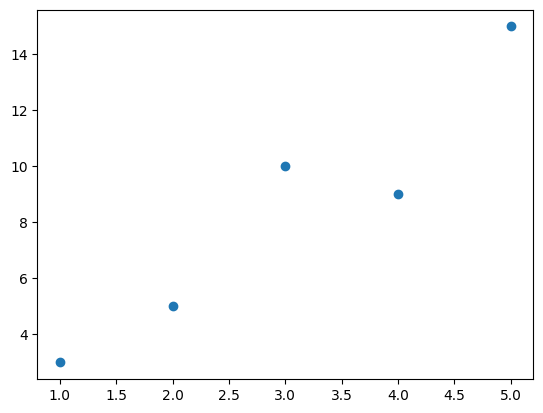

In [3]:
plt.scatter(X,y)

#### Step 3: Initialize the Parameters

In [4]:
# Initialize weights (slope) and bias (intercept)
beta_0 = 0.0
beta_1 = 0.0

# Set the learning rate and number of iterations
learning_rate = 0.01
iterations = 1000

#### Step 4: Define the Hypothesis Function

In [5]:
def predict(X, beta_0, beta_1):
    return beta_1 * X + beta_0

#### Step 5: Define the Cost Function

In [6]:
def compute_cost(X, y, beta_0, beta_1):
    m = len(y)
    predictions = predict(X, beta_0, beta_1)
    cost = (1/2*m) * np.sum((predictions - y)**2)
    return cost

#### step 6: Compute Gradients

In [7]:
def compute_gradients(X, y, beta_0, beta_1):
    m = len(y)
    predictions = predict(X, beta_0, beta_1)
    dbeta_1 = (1/m) * np.sum((predictions - y) * X)
    dbeta_0 = (1/m) * np.sum(predictions - y)
    return dbeta_1, dbeta_0

### Step 7: Update the Coefficients 

In [8]:
def update_parameters(w, b, dw, db, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b


In [9]:
dbeta_1, dbeta_0 = compute_gradients(X, y, beta_0, beta_1)
beta_1, beta_0 = update_parameters(beta_1, beta_0, dbeta_1, dbeta_0, learning_rate)

In [12]:
beta_0

np.float64(0.084)

In [13]:
beta_1

np.float64(0.308)

In [48]:
print(f"The Equation after only one iteration is: {beta_0}+{beta_1}X")

The Equation after only one iteration is: 0.084+0.308X


#### Step 8. Iterate

In [49]:
for i in range(iterations):
    dbeta_1, dbeta_0 = compute_gradients(X, y, beta_0, beta_1)
    beta_1, beta_0 = update_parameters(beta_1, beta_0, dbeta_1, dbeta_0, learning_rate)
    if i % 10 == 0:
        cost = compute_cost(X, y, beta_0, beta_1)
        print(f"Iteration {i}: Cost {cost}, beta_0: {beta_0}, beta_1: {beta_1}")

Iteration 0: Cost 673.91253848, beta_0: 0.15792, beta_1: 0.5796000000000001
Iteration 10: Cost 75.58166427681861, beta_0: 0.5468516439617696, beta_1: 2.0305829698876114
Iteration 20: Cost 27.322959780488645, beta_0: 0.6488460929775628, beta_1: 2.4448461936013146
Iteration 30: Cost 23.399997258255397, beta_0: 0.669521097096142, beta_1: 2.564748167932843
Iteration 40: Cost 23.051508699927133, beta_0: 0.6672486445950048, beta_1: 2.601043247785408
Iteration 50: Cost 22.992189688627516, beta_0: 0.6585980644391194, beta_1: 2.6135647066737646
Iteration 60: Cost 22.957216240697523, beta_0: 0.6482710555214362, beta_1: 2.6192996942623714
Iteration 70: Cost 22.92520955839325, beta_0: 0.6376001650416059, beta_1: 2.6230714434505473
Iteration 80: Cost 22.894413134140255, beta_0: 0.6269614843627281, beta_1: 2.6262498714848284
Iteration 90: Cost 22.86465308534098, beta_0: 0.6164596066242699, beta_1: 2.629224497743581
Iteration 100: Cost 22.835884160535088, beta_0: 0.606122083851169, beta_1: 2.63210649

## Lab 1: 
Task 2: Implement the Multiple Linear Regression in the dataset of your choice from scratch and Compare it with the result from sklearn.